In [ ]:
import pandas as pd
import glob
import seaborn as sns
import matplotlib.pyplot as plt

# concentrated on col 16-32
# predicting ClosePrice on PropertyType = Residential, PropertySubType = SingleFamilyResidence

csvs = (glob.glob("CRMLSSold*.csv"))

df = pd.concat((pd.read_csv(c) for c in csvs), ignore_index=True)
df = df[(df["PropertyType"] == "Residential") &
        (df["PropertySubType"] == "SingleFamilyResidence")].copy()

/tmp/ipython-input-2495165377.py:11: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat((pd.read_csv(c) for c in csvs), ignore_index=True)


In [ ]:
#check out columns (16-32) + ClosePrice

predicted_idx = df.columns.get_loc("ClosePrice")
other_indices = list(range(15, 31))
col_indices = [predicted_idx] + other_indices
df_subset = df.iloc[:, col_indices]

print(df_subset.columns)

Index(['ClosePrice', 'Longitude', 'UnparsedAddress', 'PropertyType',
       'LivingArea', 'ListPrice', 'DaysOnMarket', 'ListOfficeName',
       'BuyerOfficeName', 'CoListOfficeName', 'ListAgentFullName',
       'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId',
       'BuyerAgentFirstName', 'BuyerAgentLastName', 'FireplacesTotal'],
      dtype='object')


In [ ]:
#check for missing or abnormalities in this subset
#drop them if needed
df_subset.head()

,ClosePrice,Longitude,UnparsedAddress,PropertyType,LivingArea,ListPrice,DaysOnMarket,ListOfficeName,BuyerOfficeName,CoListOfficeName,ListAgentFullName,CoListAgentFirstName,CoListAgentLastName,BuyerAgentMlsId,BuyerAgentFirstName,BuyerAgentLastName,FireplacesTotal
3,890000.0,-117.221040,810 Marin Lane,Residential,3000.0,889000.0,181,COLDWELL BANKER SKY RIDGE REALTY,NONMEMBER MRML,NaN,MICHELLE HUTTON,NaN,NaN,nonmember,General,NONMEMBER,NaN
10,1876384.0,-118.390320,9016 Wonderland Avenue,Residential,1800.0,1899999.0,87,Compass,Compass,NaN,Chase Campen,NaN,NaN,CLW-C141531,Nicholas,Borchenko,NaN
11,4820000.0,-122.388226,2905 Privet Drive,Residential,4270.0,4820000.0,0,Green Banker Realty,Green Banker Realty,NaN,Stanley Lo,NaN,NaN,ML157878,Stanley,Lo,NaN
13,865000.0,-117.777782,3620 Vista Glen Circle,Residential,1442.0,865000.0,0,Major League Properties,Major League Properties,NaN,Matt Luke,NaN,NaN,PWCONSEA,Connor,Seaman,NaN
14,875000.0,-122.059421,19036 Clemans Dr,Residential,1086.0,875000.0,0,Alliance Bay Realty,MLSListing,NaN,Brian Rowland,NaN,NaN,CCBE-MLL479273,Brian,Rowland,NaN


In [ ]:
#not too much gone, didn't drop anything
na_rate = df_subset.isna().mean()
print(na_rate)

ClosePrice              0.000000
Longitude               0.000076
UnparsedAddress         0.000773
PropertyType            0.000000
LivingArea              0.000545
ListPrice               0.000000
DaysOnMarket            0.000000
ListOfficeName          0.000000
BuyerOfficeName         0.011261
CoListOfficeName        0.738955
ListAgentFullName       0.000291
CoListAgentFirstName    0.765846
CoListAgentLastName     0.765149
BuyerAgentMlsId         0.001229
BuyerAgentFirstName     0.004421
BuyerAgentLastName      0.000519
FireplacesTotal         1.000000
dtype: float64


Correlation Matrix:
                 ClosePrice  Longitude  LivingArea  ListPrice  DaysOnMarket  \
ClosePrice         1.000000  -0.006009    0.117155   0.179948      0.012313   
Longitude         -0.006009   1.000000    0.028186  -0.038746      0.040786   
LivingArea         0.117155   0.028186    1.000000   0.646024      0.149194   
ListPrice          0.179948  -0.038746    0.646024   1.000000      0.077585   
DaysOnMarket       0.012313   0.040786    0.149194   0.077585      1.000000   
FireplacesTotal         NaN        NaN         NaN        NaN           NaN   

                 FireplacesTotal  
ClosePrice                   NaN  
Longitude                    NaN  
LivingArea                   NaN  
ListPrice                    NaN  
DaysOnMarket                 NaN  
FireplacesTotal              NaN  


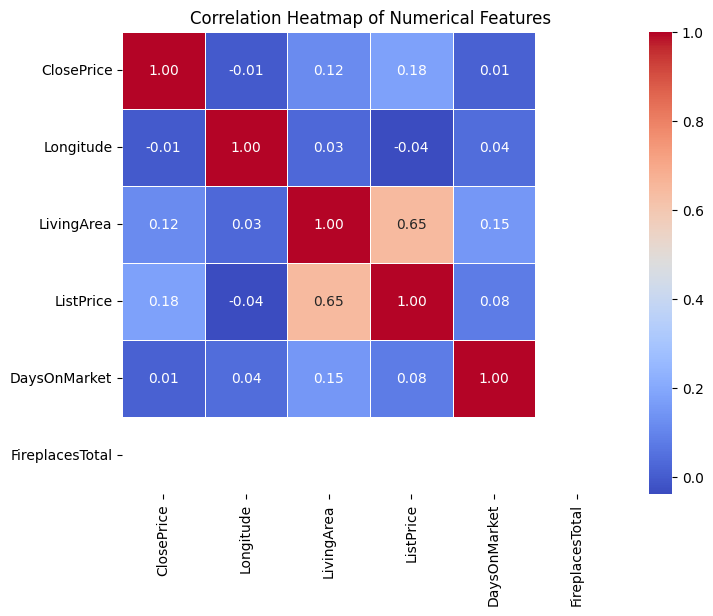

In [ ]:
#create correlation matrix
#create heatmap

correlation_matrix = df_subset.corr(numeric_only=True)
print("Correlation Matrix:")
print(correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

kinda conclude that these columns can be dropped, there's not much significance in the numerical ones


In [ ]:
#looked over at col 32-46
indices2nd = list(range(31, 46))
indices2 = [predicted_idx] + indices2nd
df_subset_2 = df.iloc[:, col_indices]

In [ ]:
na_rate2 = df_subset_2.isna().mean()
print(na_rate2)

ClosePrice              0.000000
Longitude               0.000076
UnparsedAddress         0.000773
PropertyType            0.000000
LivingArea              0.000545
ListPrice               0.000000
DaysOnMarket            0.000000
ListOfficeName          0.000000
BuyerOfficeName         0.011261
CoListOfficeName        0.738955
ListAgentFullName       0.000291
CoListAgentFirstName    0.765846
CoListAgentLastName     0.765149
BuyerAgentMlsId         0.001229
BuyerAgentFirstName     0.004421
BuyerAgentLastName      0.000519
FireplacesTotal         1.000000
dtype: float64


Correlation Matrix:
                 ClosePrice  Longitude  LivingArea  ListPrice  DaysOnMarket  \
ClosePrice         1.000000  -0.006009    0.117155   0.179948      0.012313   
Longitude         -0.006009   1.000000    0.028186  -0.038746      0.040786   
LivingArea         0.117155   0.028186    1.000000   0.646024      0.149194   
ListPrice          0.179948  -0.038746    0.646024   1.000000      0.077585   
DaysOnMarket       0.012313   0.040786    0.149194   0.077585      1.000000   
FireplacesTotal         NaN        NaN         NaN        NaN           NaN   

                 FireplacesTotal  
ClosePrice                   NaN  
Longitude                    NaN  
LivingArea                   NaN  
ListPrice                    NaN  
DaysOnMarket                 NaN  
FireplacesTotal              NaN  


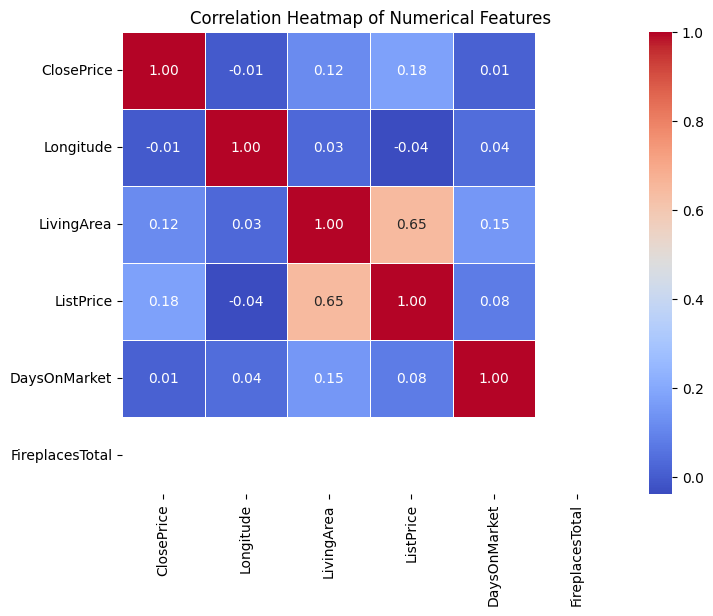

In [ ]:
#create correlation matrix
#create heatmap

correlation_matrix_2 = df_subset_2.corr(numeric_only=True)
print("Correlation Matrix:")
print(correlation_matrix_2)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_2,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()